# MEDICAL INSURANCE (ML PROJECT)

## Libraries & Tools Used

In [1]:
# =========================
# CORE LIBRARIES
# =========================
import numpy as np
import pandas as pd

# =========================
# VISUALIZATION
# =========================
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# DATA SPLITTING
# =========================
from sklearn.model_selection import train_test_split

# =========================
# PREPROCESSING
# =========================
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# =========================
# PIPELINE
# =========================
from sklearn.pipeline import Pipeline

# =========================
# MODELS (REGRESSION)
# =========================
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import AdaBoostRegressor

# =========================
# EVALUATION METRICS
# =========================
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# =========================
# MODEL TUNING
# =========================
from sklearn.model_selection import GridSearchCV

# =========================
# MODEL SAVE
# =========================
import joblib

In [2]:
df=pd.read_csv("C:/Users/User/Desktop/ML_Project/insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [3]:
print("SEX:\n")
print(df["sex"].unique())

print("\nSMOKER:\n")
print(df["smoker"].unique())

print("\nREGION:\n")
print(df["region"].unique())



SEX:

['female' 'male']

SMOKER:

['yes' 'no']

REGION:

['southwest' 'southeast' 'northwest' 'northeast']


# Data Understanding

In [4]:
print("Dataframe size:-",df.size)

Dataframe size:- 9366


In [5]:
print("Dataframe Shape:-",df.shape)

Dataframe Shape:- (1338, 7)


In [6]:
print("Column Names:-\n",df.columns)

Column Names:-
 Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')


In [7]:
print("Column DataTypes:_\n",df.dtypes)

Column DataTypes:_
 age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


In [8]:
print("Statistical Summary:-\n")
df.describe()

Statistical Summary:-



,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [9]:
print("Summary Of DataSet:_\n")
df.info()

Summary Of DataSet:_

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [10]:
print("Total NULL Values in Each Column:-\n",df.isnull().sum())

Total NULL Values in Each Column:-
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [11]:
# VARIABLE ANALYSIS

print("Total Count Of Smokers:-")
df["smoker"].value_counts()

Total Count Of Smokers:-


smoker
no     1064
yes     274
Name: count, dtype: int64

# Exploratory Data Analysis [ EDA ]

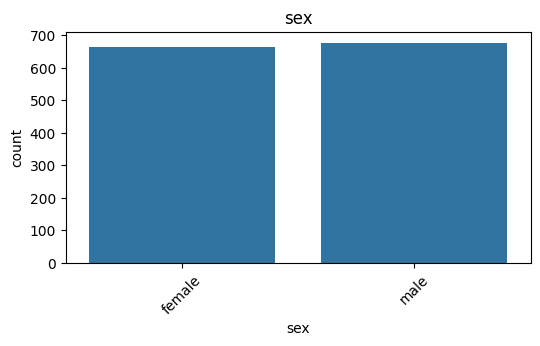

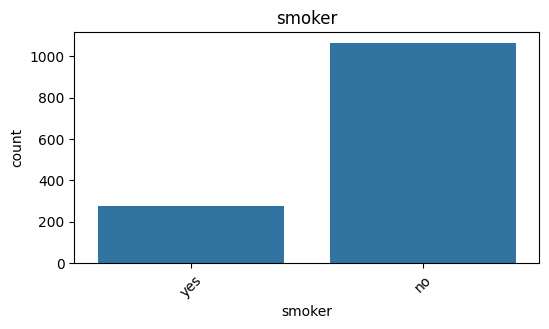

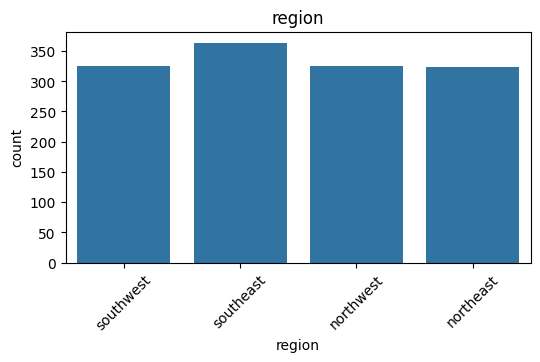

In [12]:
# CATEGORICAL FEATURES ANALYSIS

cat_cols = df.select_dtypes(include='object').columns
cat_cols

for col in cat_cols:
    plt.figure(figsize=(6,3))
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()

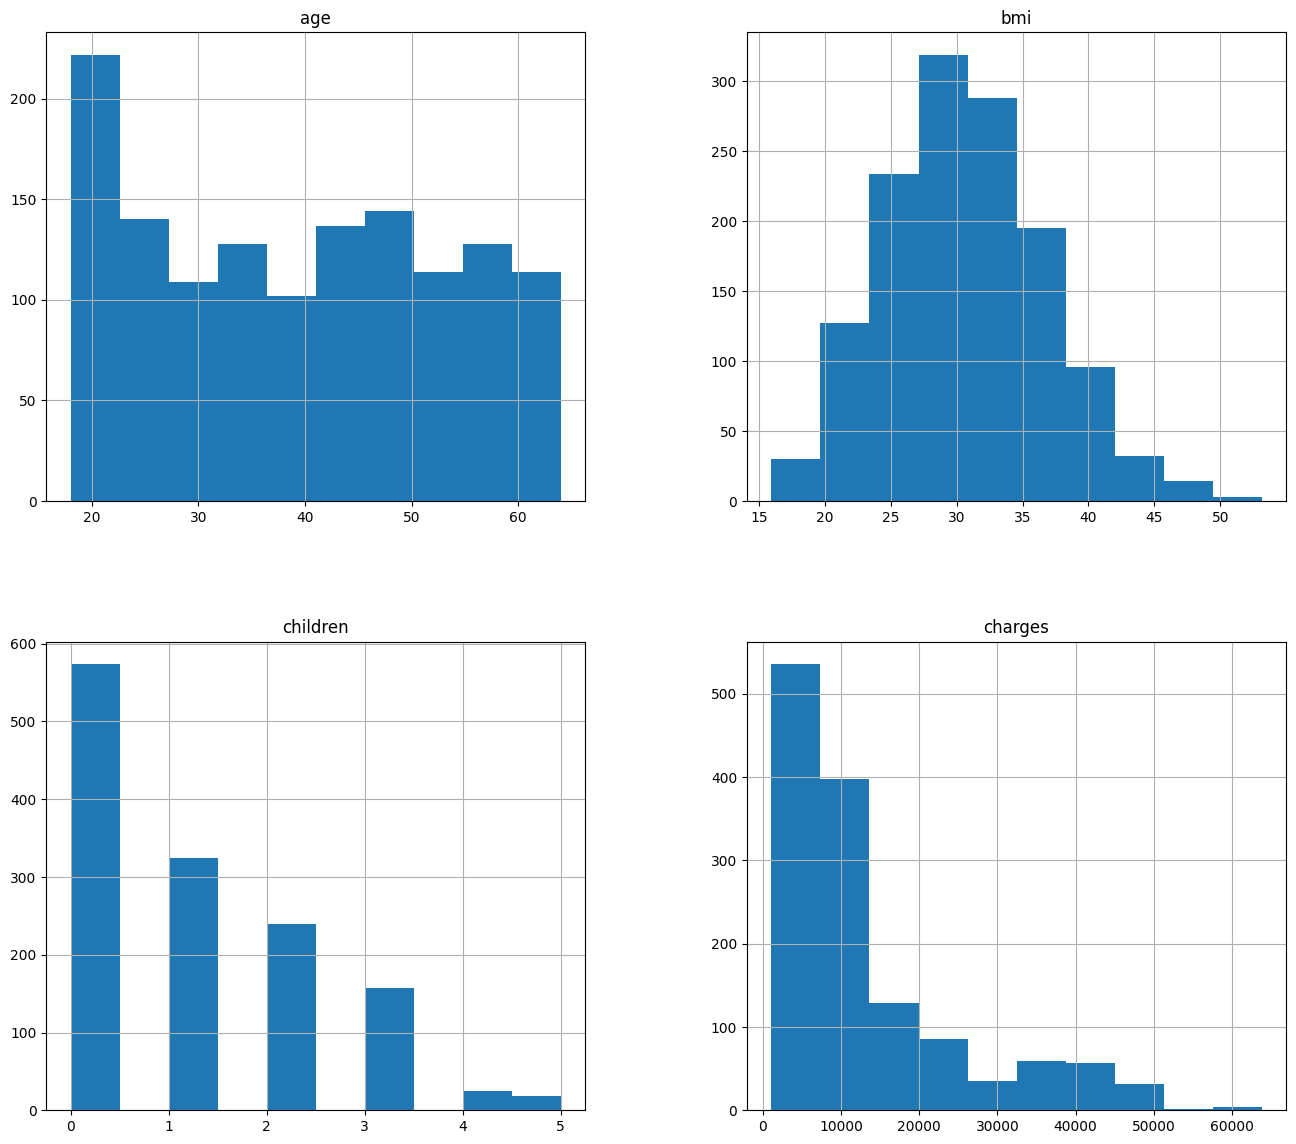

In [13]:
# NUMERICAL FEATURES ANALYSIS( HISTOGRAM )

num_cols = df.select_dtypes(include=["float64","int64"]).columns
num_cols

df[num_cols].hist(figsize=(16,14))
plt.show()

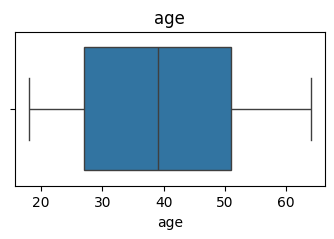

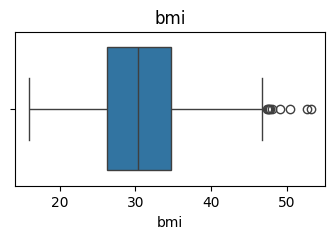

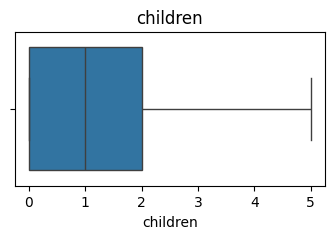

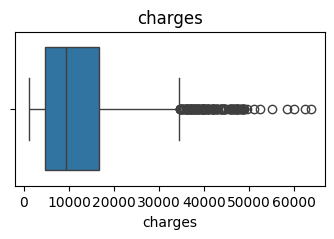

In [14]:
# BOXPLOT ( Outlier Detection )

for col in num_cols:
    plt.figure(figsize=(4,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

([0, 1, 2, 3],
 [Text(0, 0, 'age'),
  Text(1, 0, 'bmi'),
  Text(2, 0, 'children'),
  Text(3, 0, 'charges')])

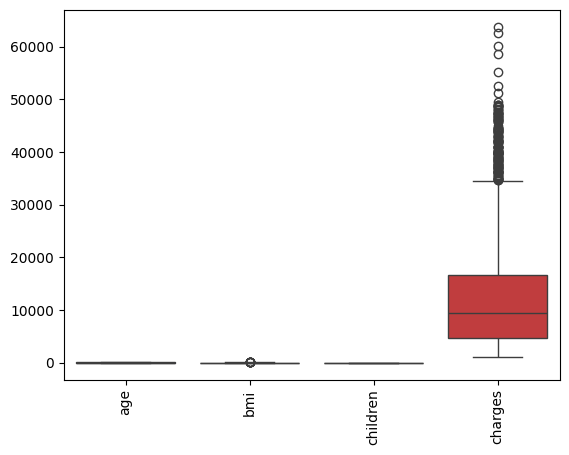

In [15]:
sns.boxplot(df)
plt.xticks(rotation=90)

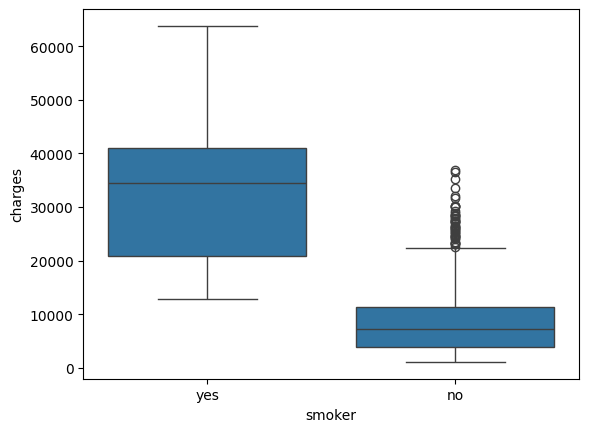

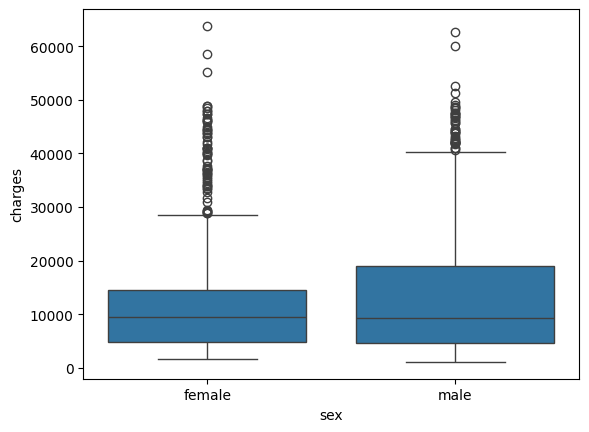

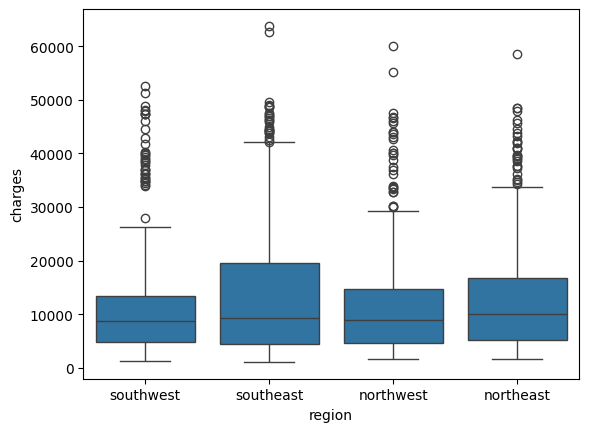

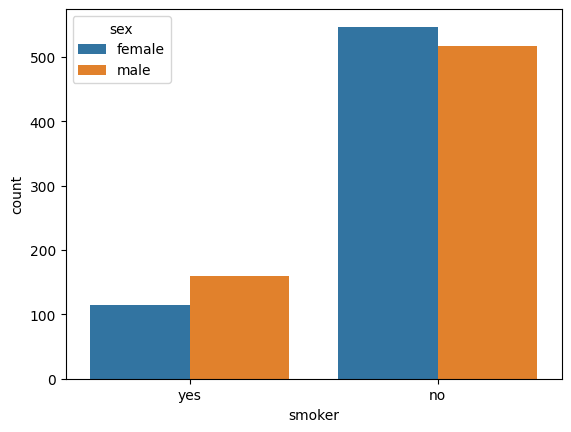

In [16]:
# CHARGES VS IMPORTANT FEATURES

# 1.Charges vs Smoker

sns.boxplot(x='smoker', y='charges', data=df)
plt.show()

# 2. Charges vs Sex

sns.boxplot(x='sex', y='charges', data=df)
plt.show()

# 3.Charges vs Region

sns.boxplot(x='region', y='charges', data=df)
plt.show()

# 4.Countplot(Smoker distribution)

sns.countplot(x='smoker', hue='sex', data=df)
plt.show()


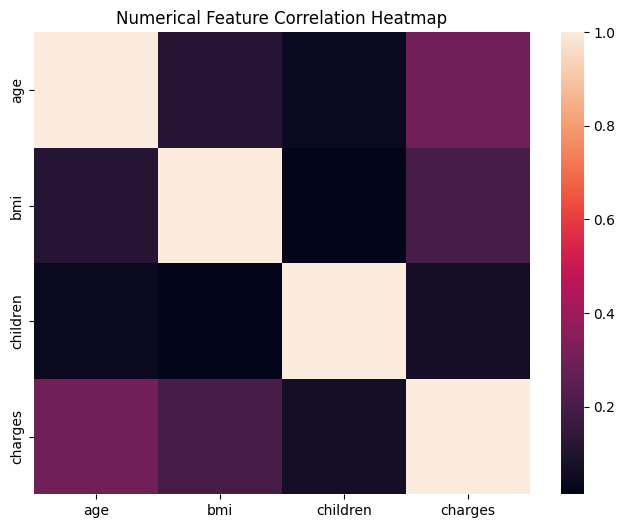

In [17]:
# CORRELATION ANALYSIS ( HEATMAP )

corr = df.select_dtypes(include=["float64","int64"]).corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr )
plt.title("Numerical Feature Correlation Heatmap")
plt.show()

# Data Cleaning & Preprocessing

# Removing Duplicates

In [18]:
# check duplicate rows

df.duplicated().sum()

np.int64(1)

# Outliers Detecting And Replacing

Outliers detected and replaced successfully


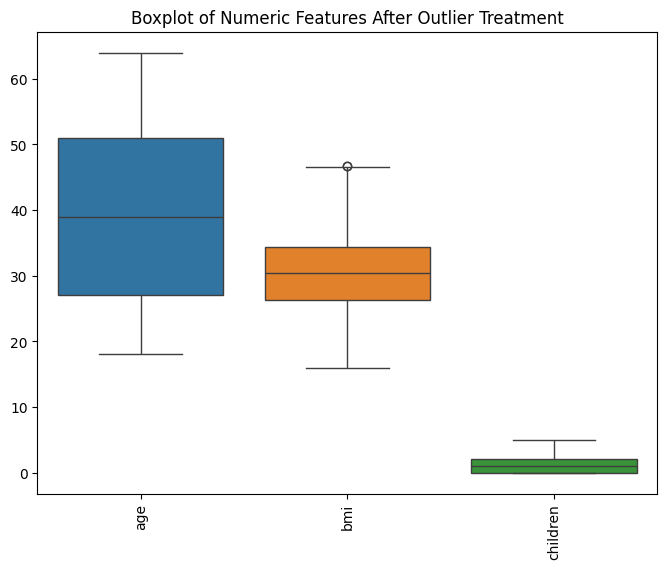

In [19]:
# Detect and replace outliers in numeric columns

numeric_cols = [col for col in df.select_dtypes(include=["float64", "int64"]).columns
                if col != "charges"]

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    median = df[col].median()
    df.loc[(df[col] < lower) | (df[col] > upper), col] = median

print("Outliers detected and replaced successfully")

# Boxplot for numeric columns

plt.figure(figsize=(8,6))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=90)
plt.title("Boxplot of Numeric Features After Outlier Treatment")
plt.show()

# Target Encoding

In [4]:
df["smoker"] = df["smoker"].map({"yes": 1, "no": 0})

## Features & Target Split

In [21]:
X = df.drop("charges", axis=1)
y = df["charges"]

# Train Test Split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)     #startify only classification maathrm use cheyyollu


# Column Separation

In [23]:
categorical_cols = X.select_dtypes(include="object").columns
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns

# Preprocessing

In [24]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
])

# REGRESSION MODELS (Multiple Regressors for Comparison)

In [25]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "AdaBoost": AdaBoostRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42)
}

## Baseline Models 

In [26]:
baseline_results = []

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    
    y_pred = pipe.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    baseline_results.append({
        "Model": name,
        "R2 Score": r2,
        "MAE": mae,
        "RMSE": rmse
    })

baseline_df = pd.DataFrame(baseline_results)
baseline_df

,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.771856,4260.835602,5951.386314
1,Decision Tree,0.725251,3079.844986,6531.034052
2,KNN,0.826159,3069.659260,5195.056811
3,SVR,-0.066846,8588.501996,12869.596989
4,Random Forest,0.864494,2559.515495,4586.622129
5,AdaBoost,0.821307,4421.259251,5267.060510
6,Gradient Boosting,0.875283,2490.816368,4400.239064
7,XGBoost,0.835710,2831.280823,5050.323338


# MODEL EVALUATION

# Regression Models Comparison (Improved Performance)

In [27]:
results = []

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    results.append({
        "Model": name,
        "R2 Score": r2_score(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
    })

results_df = pd.DataFrame(results)
results_df

,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.771856,4260.835602,5951.386314
1,Decision Tree,0.725251,3079.844986,6531.034052
2,KNN,0.826159,3069.659260,5195.056811
3,SVR,-0.066846,8588.501996,12869.596989
4,Random Forest,0.864494,2559.515495,4586.622129
5,AdaBoost,0.821307,4421.259251,5267.060510
6,Gradient Boosting,0.875283,2490.816368,4400.239064
7,XGBoost,0.835710,2831.280823,5050.323338


# HYPERPARAMETER TUNING( for all Regressors )

# Hyperparameter Tuning Using GridSearchCV

In [28]:
param_grids = {
    "Linear Regression": {},
    "Decision Tree": {"model__max_depth": [None, 10, 20]},
    "KNN": {"model__n_neighbors": [3,5,7]},
    "SVR": {"model__C": [0.1,1,10]},
    "Random Forest": {"model__n_estimators": [100,200]},
    "AdaBoost": {"model__n_estimators": [50,100]},
    "Gradient Boosting": {"model__n_estimators": [100,200]},
    "XGBoost": {"model__n_estimators": [100,200]}
}

tuned_results = []

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    grid = GridSearchCV(
        pipe,
        param_grids[name],
        scoring="r2",         #regression metric
        cv=5,
        n_jobs=-1
    )
    
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    
    tuned_results.append({
        "Model": name,
        "Best Params": grid.best_params_,
        "R2 Score": r2_score(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
    })

tuned_df = pd.DataFrame(tuned_results)
tuned_df

,Model,Best Params,R2 Score,RMSE
0,Linear Regression,{},0.771856,5951.386314
1,Decision Tree,{'model__max_depth': 10},0.779588,5849.673718
2,KNN,{'model__n_neighbors': 7},0.834475,5069.281170
3,SVR,{'model__C': 10},-0.005341,12493.113334
4,Random Forest,{'model__n_estimators': 200},0.863365,4605.694777
5,AdaBoost,{'model__n_estimators': 50},0.821307,5267.060510
6,Gradient Boosting,{'model__n_estimators': 100},0.875283,4400.239064
7,XGBoost,{'model__n_estimators': 100},0.835710,5050.323338


In [29]:
y_pred = best_model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.8357103109438282
MAE: 2831.280822613529
RMSE: 5050.323338475328


## FINAL MODEL COMPARISSION

In [30]:
final_comparison = baseline_df.merge(tuned_df, on="Model", suffixes=("_Before", "_After"))

final_comparison.sort_values(by="R2 Score_After", ascending=False)

,Model,R2 Score_Before,MAE,RMSE_Before,Best Params,R2 Score_After,RMSE_After
6,Gradient Boosting,0.875283,2490.816368,4400.239064,{'model__n_estimators': 100},0.875283,4400.239064
4,Random Forest,0.864494,2559.515495,4586.622129,{'model__n_estimators': 200},0.863365,4605.694777
7,XGBoost,0.835710,2831.280823,5050.323338,{'model__n_estimators': 100},0.835710,5050.323338
2,KNN,0.826159,3069.659260,5195.056811,{'model__n_neighbors': 7},0.834475,5069.281170
5,AdaBoost,0.821307,4421.259251,5267.060510,{'model__n_estimators': 50},0.821307,5267.060510
1,Decision Tree,0.725251,3079.844986,6531.034052,{'model__max_depth': 10},0.779588,5849.673718
0,Linear Regression,0.771856,4260.835602,5951.386314,{},0.771856,5951.386314
3,SVR,-0.066846,8588.501996,12869.596989,{'model__C': 10},-0.005341,12493.113334


### MODEL SAVE

In [31]:
joblib.dump(best_model, "project_Medical_Insurance_model.pkl")

['project_Medical_Insurance_model.pkl']

In [32]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))